In [1]:
import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt
from pathlib import Path

project_root = Path.cwd().parent
print(project_root)


/Users/jack/Documents/01_Git/01_promotion/genSecSysId/python


In [2]:
nx, nd, nw, nz, ne = 1, 1, 1, 1, 1
A, B, B2 = np.array([[0.9]]), np.array([[1.0]]), np.array([[1.1]])
C, D, D12 = np.array([[1.0]]), np.array([[0.0]]), np.array([[0.0]])
C2, D21, D22 = np.array([[1.0]]), np.array([[0.0]]), np.array([[0.0]])

In [3]:
def dzn(z):
    """Scalar deadzone: max(|z| - 1, 0) * sign(z)."""
    return np.maximum(np.abs(z) - 1, 0.0) * np.sign(z)

In [177]:
class LureModel:
    def __init__(self, A, B, B2, C, C2, D, D12, D21, psi=dzn):
        self.A = A
        self.B = B
        self.B2 = B2
        self.C = C
        self.C2 = C2
        self.D = D
        self.D12 = D12
        self.D21 = D21
        self.psi = psi
        self.nx = A.shape[0]
        self.nd = B.shape[1]
        self.ne = C.shape[0]
        self.nz = B2.shape[1]
    def step(self, x, u):
        u = np.asarray(u).reshape(-1)
        z = self.C2 @ x + self.D21 @ u
        w = self.psi(z)
        y_hat = self.C @ x + self.D @ u + self.D12 @ w
        x = self.A @ x + self.B @ u + self.B2 @ w
        return y_hat, x

    def simulate(self, x0, u_seq, apply_input_filter = False):
        X = [x0.copy()]
        Y = []
        u_filtered_seq = []
        for u in u_seq:
            if apply_input_filter:
                if u**2 > self.s**2 - self.alpha**2 * 1/self.P * X[-1]**2:
                    u_filtered = np.sqrt(self.s**2 - self.alpha**2 * 1/self.P * X[-1]**2)*np.sign(u)
                    # print(f'u is filtered from {u} to {u_filtered}')
                    u = u_filtered.reshape(-1)
            y_hat, x = self.step(X[-1], u)
            u_filtered_seq.append(u)
            X.append(x)
            Y.append(y_hat)
        return np.array(X), np.array(Y).reshape(-1), np.array(u_filtered_seq)

    def check_regional_certificate(self, eps=1e-6, alpha = 1-1e-3):
        print('---CHECK REGIONAL STABILITY ---')

        self.alpha = alpha
        # Decision variables
        P = cp.Variable((self.nx, self.nx), symmetric=True)
        L = cp.Variable((self.nz, self.nx))
        m = cp.Variable((self.nz, 1))
        M = cp.diag(m)

        # S_hat for optimizing s
        S_hat = cp.Variable((1, 1))

        # Constraints
        constraints = []

        # Main LMI: F <= -eps*I
        F = cp.bmat(
            [
                [-(alpha**2) * P, np.zeros((self.nx, self.nd)), P @ self.C2.T + L.T, P @ self.A.T],
                [np.zeros((self.nd, self.nx)), -np.eye(self.nd), self.D21.T, self.B.T],
                [self.C2 @ P + L, self.D21, -2 * M, M @ self.B2.T],
                [self.A @ P, self.B, self.B2 @ M, -P],
            ]
        )
        nF = F.shape[0]
        constraints.append(F << -eps * np.eye(nF))

        # Locality constraints: [S_hat, li; li', P] >= eps*I for each row of L
        for i in range(self.nz):
            li = L[i, :].reshape((1, -1), order="C")
            locality_lmi = cp.bmat([[S_hat, li], [li.T, P]])
            constraints.append(locality_lmi >> eps * np.eye(self.nx + 1))

        # Objective
        objective = cp.Minimize(S_hat)

        # Solve
        problem = cp.Problem(objective, constraints)
        print(f"Solving SDP with {len(constraints)} constraints using MOSEK...")

        

        problem.solve(solver=cp.MOSEK, verbose=False)
        print(f"SDP status: {problem.status}")
        if problem.status not in ["optimal"]:
            return 
        
        # print(f'F = {F.value}')
        self.P = P.value
        Pinv = np.linalg.inv(P.value)
        self.H = L.value @ Pinv
        self.X = Pinv
        self.s = np.sqrt(1/S_hat.value)
        self.y_bar = self.s*np.sqrt(self.C @ P.value @ self.C.T)
        self.M = M.value
        self.sigma = np.sqrt(self.s**2*(1 - alpha**2) )

        print(f'y_bar = {self.y_bar[0,0]:.4f}, s = {self.s[0,0]:.4f}, sigma = {self.sigma[0,0]:.4f}')

    def check_global_certificate(self, eps=1e-6, alpha = 1-1e-3):
        print(f'---CHECK GLOBAL STABILITY ---')
        # Decision variables

        P = cp.Variable((self.nx, self.nx), symmetric=True)
        m = cp.Variable((self.nz, 1))
        M = cp.diag(m)

        # Constraints
        constraints = []

        # Main LMI: F <= -eps*I
        F = cp.bmat(
            [
                [-(alpha**2) * P, np.zeros((self.nx, self.nd)), P @ self.C2.T, P @ self.A.T],
                [np.zeros((self.nd, self.nx)), -np.eye(self.nd), self.D21.T, self.B.T],
                [self.C2 @ P, self.D21, -2 * M, M @ self.B2.T],
                [self.A @ P, self.B, self.B2 @ M, -P],
            ]
        )
        nF = F.shape[0]
        constraints.append(F << -eps * np.eye(nF))

        # Objective
        objective = cp.Minimize([None])

        # Solve
        problem = cp.Problem(objective, constraints)
        print(f"Solving SDP with {len(constraints)} constraints using MOSEK...")

        problem.solve(solver=cp.MOSEK, verbose=False)
        print(f"SDP status: {problem.status}")
        if problem.status not in ["optimal"]:
            print(f'Global stability is infeasible.')
            return 
        print(F.value)

In [178]:
model = LureModel(A,B,B2,C,C2, D,D12,D21)
model.check_regional_certificate(alpha=0.99)
model.check_global_certificate(alpha = 0.99)

---CHECK REGIONAL STABILITY ---
Solving SDP with 2 constraints using MOSEK...
SDP status: optimal
y_bar = 1.0000, s = 0.4166, sigma = 0.0588
---CHECK GLOBAL STABILITY ---
Solving SDP with 1 constraints using MOSEK...
SDP status: infeasible
Global stability is infeasible.


In [179]:
print(f'P = {model.P}, s = {model.s}, y_bar = {model.y_bar}, Pinv = {model.X}, H = {model.H}, M = {model.M}')

P = [[5.76192108]], s = [[0.41659708]], y_bar = [[0.99999972]], Pinv = [[0.17355323]], H = [[-1.0000001]], M = [[5.02814063e-07]]


# Show model properties

In [180]:
N = 40
u = np.zeros((N,1))
# Invariance and input-to-state stability
u[0] = 0.4
x0 = np.array([0.0])
y_stable, x, _ = model.simulate(x0, u)

# Sufficient not necessary conditions
u = np.zeros((N,1))
u[0] = 1.09
x0 = np.array([0.0])
y_sufficient, x, _ = model.simulate(x0, u)

# Bounded input unbounded output
u = np.zeros((N,1))
u[0] = 1.2
x0 = np.array([0.0])
y_unbounded, x, _ = model.simulate(x0, u)

# No input unbounded output
u = np.zeros((N,1))
x0 = np.array([1.3])
y_no_input, x, _ = model.simulate(x0, u)

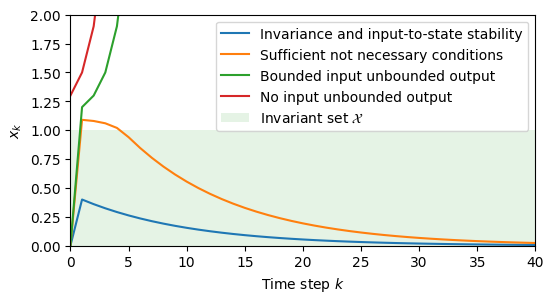

In [181]:
import tikzplotlib


fig, ax = plt.subplots(figsize=(6,3))
ax.plot(y_stable, label='Invariance and input-to-state stability')
ax.plot(y_sufficient, label='Sufficient not necessary conditions')
ax.plot(y_unbounded, label='Bounded input unbounded output')
ax.plot(y_no_input, label='No input unbounded output')
ax.axhspan(-1, 1, color="tab:green", alpha=0.12, lw=0, label='Invariant set $\mathcal{X}$')
ax.set_ylim([0, 2])
ax.set_xlim([0, N])
# ax.grid()
ax.legend()
ax.set_xlabel('Time step $k$')
ax.set_ylabel('$x_k$')
plt.show()
tikzplotlib.save(f'{project_root}/results/figures/one_D_example.tex',figure=fig)

# Show certificate properties

In [182]:
LP_CUTOFF   = 0.1  # Hz  LP filter cutoff
LP_ORDER    =   4   # Butterworth filter order
ENV_DECAY   = 0.9  # mild exponential envelope strength over one trajectory
TS = 1.0

In [186]:
def make_u(rng, T, amp_max, f_cut=LP_CUTOFF, order=LP_ORDER, env_decay=ENV_DECAY):
    """Low-pass filtered white noise with optional exponential decay envelope.

    White noise is generated at the sample rate 1/TS and filtered with a
    Butterworth LP filter of the given cutoff frequency (Hz) and order.
    The resulting signal is multiplied by exp(-env_decay * t_norm), where
    t_norm spans [0, 1], then peak-normalised to a random fraction of amp_max.
    """
    from scipy.signal import butter, filtfilt
    # design filter (normalised cutoff = f_cut / Nyquist)
    b, a = butter(order, f_cut / (0.5 / TS), btype='low')
    # generate and filter; use extra samples to avoid edge transients
    pad   = 4 * order
    noise = rng.standard_normal(T + pad)
    u_filt = filtfilt(b, a, noise)[pad:]
    # apply mild exponential decay envelope across trajectory length
    t_norm = np.linspace(0.0, 1.0, T)
    envelope = np.exp(-env_decay * t_norm)
    u_filt = u_filt * envelope
    # peak-normalise to a random fraction of amp_max
    peak = np.max(np.abs(u_filt))
    if peak > 0:
        u_filt = u_filt / peak * rng.uniform(0.0, amp_max)
    return u_filt


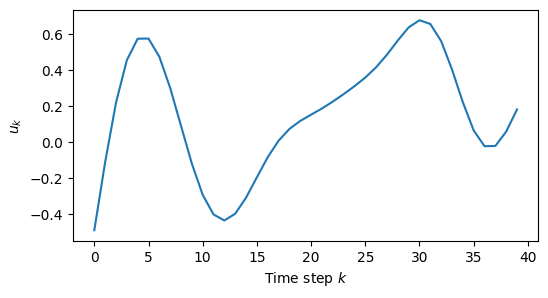

In [187]:
rng_dbg = np.random.default_rng(0)
u = make_u(rng_dbg, N, 1.5)

fig, ax = plt.subplots(figsize=(6,3))
ax.plot(u, label='Input signal $u_k$')
ax.set_xlabel('Time step $k$')
ax.set_ylabel('$u_k$')
plt.show()

In [188]:
u = u.reshape(-1, 1)

In [189]:
# input map
s = model.s
P = model.P
# invariant state set
x_max = np.sqrt(s**2 * P)

alpha = 0.99

x0 = np.array([0.0])

# static input certificate
delta = s**2*(1 - alpha**2)
u_static = np.clip(u, -np.sqrt(delta), np.sqrt(delta))
y_static, x_static, _ = model.simulate(x0, u_static, apply_input_filter=False)

# dynamic input certificate
# u^2 \leq s^2 - \alpha^2 * x^2 * P^{-1}
y_dynamic, x_dynamic, u_dynamic = model.simulate(x0, u, apply_input_filter=True)

# no input filter
y, x, u = model.simulate(x0, u, apply_input_filter=False)





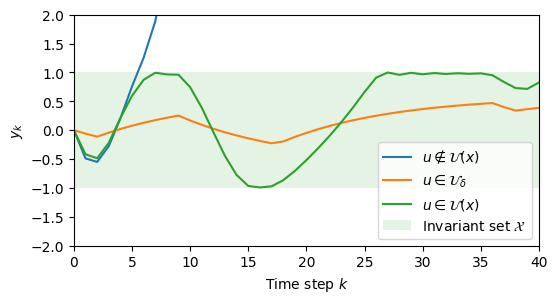

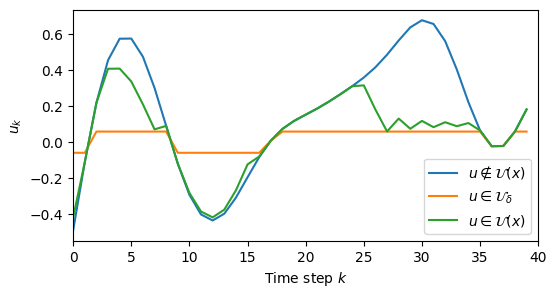

In [197]:
fig, ax = plt.subplots(figsize=(6,3))
ax.plot(y, label=r'$u \notin \mathcal{U}(x)$')
ax.plot(y_static, label=r'$u \in \mathcal{U}_\delta$')
ax.plot(y_dynamic, label=r'$u \in \mathcal{U}(x)$')
ax.axhspan(-x_max.squeeze(), x_max.squeeze(), color="tab:green", alpha=0.12, lw=0, label='Invariant set $\mathcal{X}$')
ax.legend()
ax.set_xlabel('Time step $k$')
ax.set_ylabel('$y_k$')
ax.set_xlim([0, N])
ax.set_ylim([-2, 2])
plt.show()
tikzplotlib.save(f'{project_root}/results/figures/one_D_example-certificate_properties-output.tex',figure=fig)

fig, ax = plt.subplots(figsize=(6,3))
ax.plot(u, label=r'$u \notin \mathcal{U}(x)$')
ax.plot(u_static, label=r'$u \in \mathcal{U}_\delta$')
ax.plot(u_dynamic, label=r'$u \in \mathcal{U}(x)$')
ax.set_xlabel('Time step $k$')
ax.set_ylabel('$u_k$')
ax.set_xlim([0, N])
ax.legend()
plt.show()
tikzplotlib.save(f'{project_root}/results/figures/one_D_example-certificate_properties-input.tex',figure=fig)